In [ ]:
# Binary classification using linear and logitic regression
# X_test , y_pred :- Simple model score
# X_test , y_test :- X_test value internally test/train then score
# y_test , y_test :- compare behave

In [4]:
import numpy as np
x = np.random.random(30)
x

array([0.07711302, 0.71075402, 0.9031985 , 0.155049  , 0.67258838,
       0.50245147, 0.30505461, 0.6094805 , 0.85715336, 0.44814005,
       0.96221722, 0.98584615, 0.47614111, 0.34117079, 0.53626234,
       0.42633693, 0.72889115, 0.91068602, 0.53017615, 0.36057594,
       0.79341704, 0.38361249, 0.0766941 , 0.8216996 , 0.33091912,
       0.94092844, 0.78521597, 0.06143179, 0.16639492, 0.99327772])

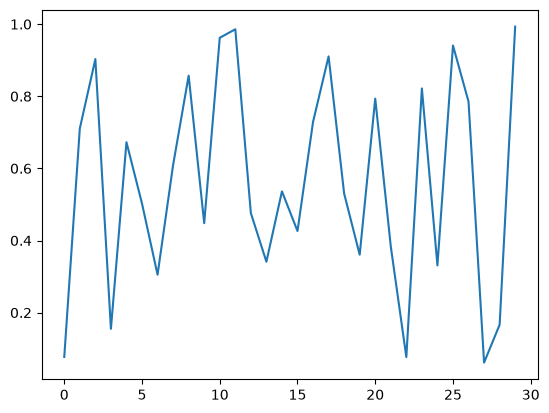

In [42]:
import matplotlib.pyplot as plt
plt.plot(x)
plt.show()

In [ ]:
#create sigmoid function
def sigmoid(x):
    return 1/(1+2.71828**(-x))

In [139]:
sigmoid_x = sigmoid(x)
sigmoid_x

array([0.5192687 , 0.67056764, 0.71160623, 0.53868476, 0.6620824 ,
       0.62303518, 0.57567764, 0.64782219, 0.70206545, 0.61019685,
       0.72356538, 0.72826655, 0.61683617, 0.58447484, 0.63094243,
       0.60499855, 0.67456179, 0.7131404 , 0.62952411, 0.58917979,
       0.68856445, 0.59474403, 0.51916412, 0.69459688, 0.58198294,
       0.71928703, 0.68680307, 0.51535311, 0.54150299, 0.72973471])

In [140]:
sigmoid(y_pred)

array([0.61771427, 0.62931523, 0.7452523 , 0.69085289, 0.51277365,
       0.49090856, 0.72048042, 0.748817  , 0.66394196, 0.76134973,
       0.50804383, 0.71099429, 0.71457066, 0.50861596, 0.71643085,
       0.69359446, 0.70690544, 0.50075491, 0.73774046, 0.67458512])

In [141]:
final_y_pred = [round(i) for i in sigmoid(y_pred)]
final_y_pred

[1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

In [16]:
import pandas as pd
from sklearn.linear_model import LinearRegression,LogisticRegression

In [18]:
df = pd.read_csv("79.myinsurance.csv")

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Customer_ID         100 non-null    int64
 1   Age                 100 non-null    int64
 2   Gender              100 non-null    str  
 3   Annual_Income       100 non-null    int64
 4   Employment_Status   100 non-null    int64
 5   Marital_Status      100 non-null    str  
 6   Married             100 non-null    int64
 7   Previous_Insurance  100 non-null    int64
 8   Family_Size         100 non-null    int64
 9   Buy_Insurance       100 non-null    str  
dtypes: int64(7), str(3)
memory usage: 7.9 KB


In [84]:
df.shape


(100, 10)

In [85]:
df.columns

Index(['Customer_ID', 'Age', 'Gender', 'Annual_Income', 'Employment_Status',
       'Marital_Status', 'Married', 'Previous_Insurance', 'Family_Size',
       'Buy_Insurance'],
      dtype='str')

In [106]:
#corr() only take numeric data
df.corr(numeric_only=True)

,Age,Annual_Income,Employment_Status,Married,Previous_Insurance,Family_Size
Age,1.000000,0.998332,0.650960,0.834590,0.960055,0.956927
Annual_Income,0.998332,1.000000,0.650526,0.839337,0.961360,0.957596
Employment_Status,0.650960,0.650526,1.000000,0.557578,0.610820,0.689424
Married,0.834590,0.839337,0.557578,1.000000,0.820608,0.848247
Previous_Insurance,0.960055,0.961360,0.610820,0.820608,1.000000,0.933681
Family_Size,0.956927,0.957596,0.689424,0.848247,0.933681,1.000000


In [107]:
text_data = list[df.select_dtypes(str).columns]
text_data

list[Index([], dtype='str')]

In [108]:
df.sample()

,Age,Gender,Annual_Income,Employment_Status,Marital_Status,Married,Previous_Insurance,Family_Size,Buy_Insurance
84,34,0,49000,1,1,0,1,2,1


In [109]:
for i in text_data:
    print(f"Analysis Data {i}")
    display(df[i].value_counts())

Analysis Data *list[Index([], dtype='str')]


Age  Gender  Annual_Income  Employment_Status  Marital_Status  Married  Previous_Insurance  Family_Size  Buy_Insurance
25   1       30000          0                  1               0        0                   1            0                2
30   1       40000          1                  1               0        1                   2            1                2
40   0       60000          1                  0               1        2                   3            1                2
22   0       25000          0                  1               0        0                   1            0                1
28   0       35000          1                  1               0        0                   1            0                1
                                                                                                                         ..
35   1       52000          1                  0               1        1                   2            1                1
46   1       

In [110]:
df["Gender"]=df["Gender"].replace({'Male':0, 'Female':1})
df

,Age,Gender,Annual_Income,Employment_Status,Marital_Status,Married,Previous_Insurance,Family_Size,Buy_Insurance
0,22,0,25000,0,1,0,0,1,0
1,25,1,30000,0,1,0,0,1,0
2,28,0,35000,1,1,0,0,1,0
3,30,1,40000,1,1,0,1,2,1
4,32,0,45000,1,1,0,1,2,1
...,...,...,...,...,...,...,...,...,...
95,46,1,70000,1,0,1,2,4,1
96,51,0,83000,1,0,1,3,4,1
97,56,1,94000,1,0,1,3,4,1
98,24,0,31000,0,1,0,0,1,0


In [111]:
df["Buy_Insurance"]=df["Buy_Insurance"].replace({'No':0, 'Yes':1})
df

,Age,Gender,Annual_Income,Employment_Status,Marital_Status,Married,Previous_Insurance,Family_Size,Buy_Insurance
0,22,0,25000,0,1,0,0,1,0
1,25,1,30000,0,1,0,0,1,0
2,28,0,35000,1,1,0,0,1,0
3,30,1,40000,1,1,0,1,2,1
4,32,0,45000,1,1,0,1,2,1
...,...,...,...,...,...,...,...,...,...
95,46,1,70000,1,0,1,2,4,1
96,51,0,83000,1,0,1,3,4,1
97,56,1,94000,1,0,1,3,4,1
98,24,0,31000,0,1,0,0,1,0


In [112]:
df["Marital_Status"]=df["Marital_Status"].replace({'Married':1, 'Single':0})
df

,Age,Gender,Annual_Income,Employment_Status,Marital_Status,Married,Previous_Insurance,Family_Size,Buy_Insurance
0,22,0,25000,0,1,0,0,1,0
1,25,1,30000,0,1,0,0,1,0
2,28,0,35000,1,1,0,0,1,0
3,30,1,40000,1,1,0,1,2,1
4,32,0,45000,1,1,0,1,2,1
...,...,...,...,...,...,...,...,...,...
95,46,1,70000,1,0,1,2,4,1
96,51,0,83000,1,0,1,3,4,1
97,56,1,94000,1,0,1,3,4,1
98,24,0,31000,0,1,0,0,1,0


In [113]:
df.corr()

,Age,Gender,Annual_Income,Employment_Status,Marital_Status,Married,Previous_Insurance,Family_Size,Buy_Insurance
Age,1.000000,0.018621,0.998332,0.650960,-0.834590,0.834590,0.960055,0.956927,0.727278
Gender,0.018621,1.000000,0.017779,-0.023762,0.020004,-0.020004,0.018322,0.008821,0.021622
Annual_Income,0.998332,0.017779,1.000000,0.650526,-0.839337,0.839337,0.961360,0.957596,0.729951
Employment_Status,0.650960,-0.023762,0.650526,1.000000,-0.557578,0.557578,0.610820,0.689424,0.815384
Marital_Status,-0.834590,0.020004,-0.839337,-0.557578,1.000000,-1.000000,-0.820608,-0.848247,-0.683822
Married,0.834590,-0.020004,0.839337,0.557578,-1.000000,1.000000,0.820608,0.848247,0.683822
Previous_Insurance,0.960055,0.018322,0.961360,0.610820,-0.820608,0.820608,1.000000,0.933681,0.749119
Family_Size,0.956927,0.008821,0.957596,0.689424,-0.848247,0.848247,0.933681,1.000000,0.769227
Buy_Insurance,0.727278,0.021622,0.729951,0.815384,-0.683822,0.683822,0.749119,0.769227,1.000000


In [118]:
X = df.drop(columns = "Buy_Insurance")
y = df["Buy_Insurance"]

In [115]:
X.shape

(100, 8)

In [80]:
from sklearn.model_selection import train_test_split

In [125]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=43)

In [126]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(80, 8)
(20, 8)
(80,)
(20,)


In [127]:
model=LinearRegression()
model

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [128]:
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](8,)","[-0.05, 0.07, 0. ,..., 0.05, 0.28, 0.11]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](8,)","['Age','Gender','Annual_Income',...,'Married','Previous_Insurance', 'Family_Size']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.7962
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,8
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(7)


In [129]:
y_pred=model.predict(X_test)
y_pred

array([ 0.47985799,  0.52928062,  1.07344988,  0.80411021,  0.05110574,
       -0.03636979,  0.94684651,  1.0923136 ,  0.68091132,  1.16009442,
        0.03217814,  0.90021855,  0.91768801,  0.03446727,  0.92682635,
        0.81697849,  0.88040221,  0.00301963,  1.03425816,  0.72899743])

In [130]:
y_test

20    1
2     0
15    1
22    1
57    0
91    0
69    1
55    1
11    0
79    1
9     0
38    1
85    1
0     0
89    1
13    1
5     1
1     0
95    1
83    0
Name: Buy_Insurance, dtype: object

In [151]:
sigmoid(y_pred)

array([0.61771427, 0.62931523, 0.7452523 , 0.69085289, 0.51277365,
       0.49090856, 0.72048042, 0.748817  , 0.66394196, 0.76134973,
       0.50804383, 0.71099429, 0.71457066, 0.50861596, 0.71643085,
       0.69359446, 0.70690544, 0.50075491, 0.73774046, 0.67458512])

In [153]:
final_y_pred = [round(i) for i in sigmoid(y_pred)]
final_y_pred

[1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

In [156]:
score = model.score(X_test, y_test)
score

0.6450551271910135

In [157]:
model_logistic = LogisticRegression()
model_logistic

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following

In [161]:
#model_logistic.fit(X_train,y_train)
y_train.dtype

AttributeError: 'function' object has no attribute 'dtype'

In [150]:
y_pred = model.predict(X_test)
y_pred

array([ 0.47985799,  0.52928062,  1.07344988,  0.80411021,  0.05110574,
       -0.03636979,  0.94684651,  1.0923136 ,  0.68091132,  1.16009442,
        0.03217814,  0.90021855,  0.91768801,  0.03446727,  0.92682635,
        0.81697849,  0.88040221,  0.00301963,  1.03425816,  0.72899743])